# Notebook 3: Multivariate Test Analysis

## Campaign Experimentation Framework

This notebook analyzes **EXP-002: Landing Page Multivariate Test** — a 4-variant test examining different landing page designs on form submission rate.

### The Central Challenge: Multiple Comparisons

When testing 4 variants, we have **6 pairwise comparisons** (C vs A, B vs A, D vs A, B vs C, C vs D, B vs D). If each test uses α=0.05, the probability of at least one false positive is:

$$P(\text{at least one false positive}) = 1 - (1 - 0.05)^6 \approx 26\%$$

This notebook demonstrates how the four correction methods (Bonferroni, Holm, FDR-BH, Dunnett) address this problem and when to use each.

**Variants:**
- `control` — current landing page
- `variant_a` — new hero image
- `variant_b` — simplified form (fewer fields)
- `variant_c` — social proof redesign

## 1. Setup

In [1]:
import sys
import os
from pathlib import Path

PROJECT_ROOT = Path(os.path.abspath(os.path.join(os.getcwd(), "..")))
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import display, Image
import warnings
warnings.filterwarnings("ignore")

from config import SIGNIFICANCE_LEVEL, CONFIDENCE_LEVEL, VISUALS_DIR, DATA_DIR
from src.multivariate_test import MultivariateTest
from src.visualizations import ExperimentVisualizer

DATA_PATH = PROJECT_ROOT / DATA_DIR
VISUALS_PATH = PROJECT_ROOT / VISUALS_DIR
VISUALS_PATH.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH / "exp002_landing_page_mvt.csv")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"Variants: {sorted(df['variant'].unique())}")

Shape: (80000, 10)
Columns: ['contact_id', 'variant', 'bounce_rate', 'form_submit_rate', 'demo_request_rate', 'time_on_page', 'industry', 'company_size', 'region', 'engagement_tier']
Variants: ['control', 'variant_b', 'variant_c', 'variant_d']


## 2. Data Overview

In [2]:
print("Variant counts:")
print(df["variant"].value_counts().sort_index().to_string())

metrics = ["form_submit_rate", "demo_request_rate", "bounce_rate"]
print("\nPer-variant metric summaries:")
display(df.groupby("variant")[metrics].mean().round(4))

print("\nSample size by variant:")
print(df.groupby("variant").size().rename("n").to_string())

Variant counts:
variant
control      20000
variant_b    20000
variant_c    20000
variant_d    20000

Per-variant metric summaries:


,form_submit_rate,demo_request_rate,bounce_rate
variant,,,
control,0.0795,0.0196,0.4497
variant_b,0.0842,0.0212,0.4334
variant_c,0.1080,0.0248,0.3847
variant_d,0.0890,0.0304,0.3916



Sample size by variant:
variant
control      20000
variant_b    20000
variant_c    20000
variant_d    20000


## 3. The Multiple Comparison Problem

Let's compute raw (uncorrected) p-values for all pairwise comparisons on `form_submit_rate` to illustrate the false positive inflation problem.

In [3]:
from scipy import stats as scipy_stats
import itertools

variants = sorted(df["variant"].unique())
metric_col = "form_submit_rate"

# Compute per-variant rates
var_stats = {}
for v in variants:
    sub = df[df["variant"] == v][metric_col]
    var_stats[v] = {"n": len(sub), "successes": int(sub.sum()), "rate": sub.mean()}

print("Variant rates on form_submit_rate:")
for v, s in var_stats.items():
    print(f"  {v:<15} n={s['n']:>5}  successes={s['successes']:>4}  rate={s['rate']:.4f}")

# All pairwise raw p-values
pairs = list(itertools.combinations(variants, 2))
raw_pvals = []
for v1, v2 in pairs:
    s1, n1 = var_stats[v1]["successes"], var_stats[v1]["n"]
    s2, n2 = var_stats[v2]["successes"], var_stats[v2]["n"]
    p_pool = (s1 + s2) / (n1 + n2)
    se = np.sqrt(p_pool * (1 - p_pool) * (1/n1 + 1/n2))
    z = ((s1/n1) - (s2/n2)) / se if se > 0 else 0
    p = float(2 * scipy_stats.norm.sf(abs(z)))
    raw_pvals.append(p)

raw_df = pd.DataFrame({
    "comparison": [f"{v1} vs {v2}" for v1, v2 in pairs],
    "p_uncorrected": raw_pvals,
    "significant_naive": [p < 0.05 for p in raw_pvals]
})

print("\nRaw (uncorrected) p-values:")
display(raw_df)

n_sig = raw_df["significant_naive"].sum()
print(f"\nSignificant at alpha=0.05 (uncorrected): {n_sig}/{len(pairs)} comparisons")
print(f"Expected false positives under H0: {0.05 * len(pairs):.2f}")
print(f"P(at least one false positive): {1 - 0.95**len(pairs):.2%}")

Variant rates on form_submit_rate:
  control         n=20000  successes=1589  rate=0.0795
  variant_b       n=20000  successes=1684  rate=0.0842
  variant_c       n=20000  successes=2160  rate=0.1080
  variant_d       n=20000  successes=1779  rate=0.0890

Raw (uncorrected) p-values:


,comparison,p_uncorrected,significant_naive
0,control vs variant_b,8.310325e-02,False
1,control vs variant_c,1.171427e-22,True
2,control vs variant_d,6.236574e-04,True
3,variant_b vs variant_c,6.734784e-16,True
4,variant_b vs variant_d,9.119613e-02,False
5,variant_c vs variant_d,1.620619e-10,True



Significant at alpha=0.05 (uncorrected): 4/6 comparisons
Expected false positives under H0: 0.30
P(at least one false positive): 26.49%


## 4. Applying Multiple Comparison Corrections

The `MultivariateTest.analyze()` dispatcher applies all four correction methods simultaneously. The `correction_comparison_table` attribute shows every comparison under each method, making it easy to see which conclusions are robust.

In [4]:
mt = MultivariateTest(
    significance_level=SIGNIFICANCE_LEVEL,
    confidence_level=CONFIDENCE_LEVEL
)

# Analyze all metrics
mvt_results = mt.analyze(
    experiment_data=df,
    variant_col="variant",
    metrics=metrics,
    experiment_id="EXP-002",
    control_variant="control"
)

# Show correction comparison table for primary metric
primary_result = mvt_results["form_submit_rate"]
print("Correction comparison table for form_submit_rate:")
corr_table = primary_result.correction_comparison_table
display(corr_table)

Correction comparison table for form_submit_rate:


,comparison,p_uncorrected,p_bonferroni,p_holm,p_fdr_bh,p_dunnett,sig_bonferroni,sig_holm,sig_fdr_bh,sig_dunnett
0,control vs variant_b,8.310325e-02,2.493098e-01,8.310325e-02,8.310325e-02,8.310325e-02,False,False,False,False
1,control vs variant_c,1.171427e-22,3.514282e-22,3.514282e-22,3.514282e-22,3.514282e-22,True,True,True,True
2,control vs variant_d,6.236574e-04,1.870972e-03,1.247315e-03,9.354861e-04,1.247315e-03,True,True,True,True


In [5]:
# Also use the helper method for the same table
print("\nBuilding correction table via build_correction_comparison_table():")
corr_table2 = mt.build_correction_comparison_table(primary_result)
display(corr_table2)

print("\nNote how Bonferroni is the most conservative (largest adjusted p-values)")
print("FDR-BH is the least conservative — appropriate when false discovery rate matters more than FWER")


Building correction table via build_correction_comparison_table():


,comparison,p_uncorrected,p_bonferroni,p_holm,p_fdr_bh,p_dunnett,sig_bonferroni,sig_holm,sig_fdr_bh,sig_dunnett
0,control vs variant_b,0.083103,0.249310,0.083103,0.083103,0.083103,False,False,False,False
1,control vs variant_c,0.000000,0.000000,0.000000,0.000000,0.000000,True,True,True,True
2,control vs variant_d,0.000624,0.001871,0.001247,0.000935,0.000935,True,True,True,True



Note how Bonferroni is the most conservative (largest adjusted p-values)
FDR-BH is the least conservative — appropriate when false discovery rate matters more than FWER


## 5. Visualizing Corrections

The `plot_probability_best()` chart shows the Bayesian probability that each variant is the best. This provides an intuitive complement to the frequentist correction tables.

Bayesian P(being best) for form_submit_rate:
  variant_c      : 1.0000 (100.0%)
  control        : 0.0000 (0.0%)
  variant_b      : 0.0000 (0.0%)
  variant_d      : 0.0000 (0.0%)

Plot saved: C:\Users\syeda\campaign-experimentation-framework\visuals\EXP-002_prob_best_form_submit_rate.png


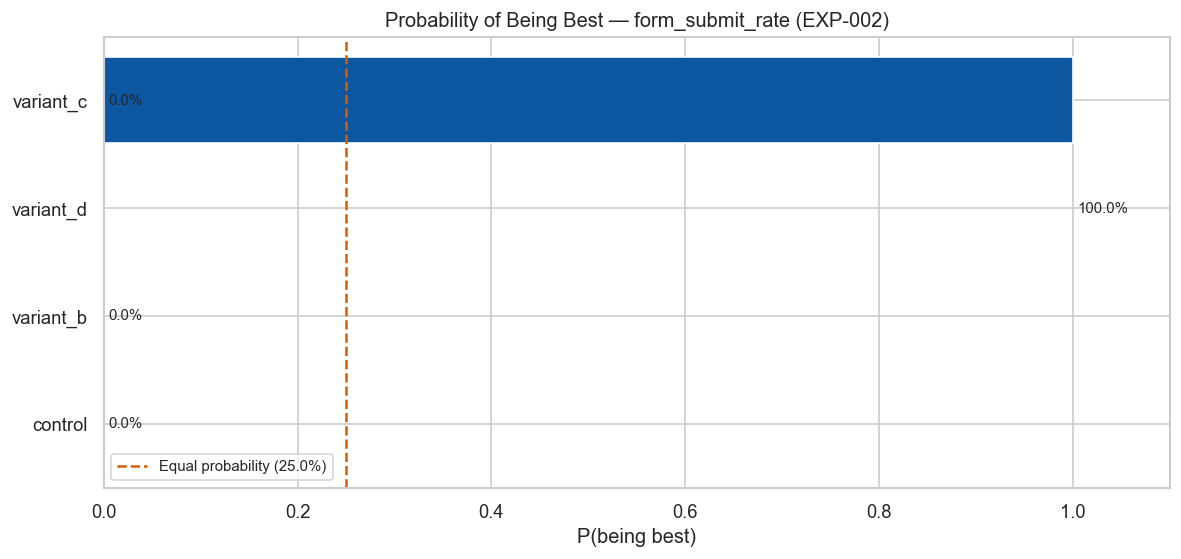

In [6]:
visualizer = ExperimentVisualizer(visuals_dir=VISUALS_PATH)

# Probability of being best for the primary metric
prob_best = primary_result.probability_best_bayesian
print("Bayesian P(being best) for form_submit_rate:")
for v, p in sorted(prob_best.items(), key=lambda x: x[1], reverse=True):
    print(f"  {v:<15}: {p:.4f} ({p:.1%})")

prob_best_path = visualizer.plot_probability_best(
    prob_best=prob_best,
    experiment_id="EXP-002",
    metric_name="form_submit_rate"
)
print(f"\nPlot saved: {prob_best_path}")
display(Image(filename=prob_best_path))

## 6. Bayesian P(Being Best)

The `probability_best_bayesian` dictionary shows the probability that each variant achieves the highest conversion rate, computed via Monte Carlo sampling from Normal posteriors seeded at each variant's observed mean.

In [7]:
# Show prob best across all metrics
for metric_name, result in mvt_results.items():
    pb = result.probability_best_bayesian
    best_variant = max(pb, key=pb.get)
    print(f"{metric_name:<22} | best={best_variant:<15} P={pb[best_variant]:.2%} | "
          + " | ".join(f"{v}={p:.1%}" for v, p in sorted(pb.items())))

form_submit_rate       | best=variant_c       P=100.00% | control=0.0% | variant_b=0.0% | variant_c=100.0% | variant_d=0.0%
demo_request_rate      | best=variant_d       P=99.97% | control=0.0% | variant_b=0.0% | variant_c=0.0% | variant_d=100.0%
bounce_rate            | best=control         P=99.94% | control=99.9% | variant_b=0.1% | variant_c=0.0% | variant_d=0.0%


## 7. Winner Declaration

The framework determines a winner based on statistical significance across multiple corrections and Bayesian probability. "High" confidence means the winner is significant under Bonferroni (the most conservative correction).

In [8]:
print("=" * 60)
print("WINNER DECLARATION — EXP-002 Landing Page MVT")
print("=" * 60)

for metric_name, result in mvt_results.items():
    print(f"\nMetric: {metric_name}")
    print(f"  Omnibus chi2 p-value: {result.overall_chi2_p_value:.4f}")
    print(f"  Winner:              {result.winner if result.winner else 'No clear winner'}")
    print(f"  Winner confidence:   {result.winner_confidence}")
    print("  Variant ranks:")
    for r in result.variant_ranks:
        print(f"    Rank {r['rank']}: {r['variant']:<15} mean={r['mean']:.4f}")

print("\nPrimary metric winner reasoning:")
pr = mvt_results["form_submit_rate"]
print(f"  The winner ({pr.winner}) has the highest mean form_submit_rate.")
print(f"  This finding holds under Bonferroni correction: confidence='{pr.winner_confidence}'")

WINNER DECLARATION — EXP-002 Landing Page MVT

Metric: form_submit_rate
  Omnibus chi2 p-value: 0.0000
  Winner:              variant_c
  Winner confidence:   high
  Variant ranks:
    Rank 1: variant_c       mean=0.1080
    Rank 2: variant_d       mean=0.0890
    Rank 3: variant_b       mean=0.0842
    Rank 4: control         mean=0.0795

Metric: demo_request_rate
  Omnibus chi2 p-value: 0.0000
  Winner:              variant_d
  Winner confidence:   high
  Variant ranks:
    Rank 1: variant_d       mean=0.0303
    Rank 2: variant_c       mean=0.0249
    Rank 3: variant_b       mean=0.0212
    Rank 4: control         mean=0.0197

Metric: bounce_rate
  Omnibus chi2 p-value: 0.0000
  Winner:              No clear winner
  Winner confidence:   none
  Variant ranks:
    Rank 1: control         mean=0.4497
    Rank 2: variant_b       mean=0.4334
    Rank 3: variant_d       mean=0.3916
    Rank 4: variant_c       mean=0.3847

Primary metric winner reasoning:
  The winner (variant_c) has the 

## 8. Handling No Clear Winner: Variant B Analysis

A common mistake is to declare a variant winner when multiple variants are statistically indistinguishable. Below we examine the pairwise results in detail to understand why some comparisons are inconclusive.

In [9]:
print("Pairwise comparisons for form_submit_rate:")
print("-" * 90)
for pw in pr.pairwise_comparisons:
    print(f"  {pw.control_variant} vs {pw.treatment_variant}:")
    print(f"    Control rate   : {pw.control_metric:.4f}")
    print(f"    Treatment rate : {pw.treatment_metric:.4f}")
    print(f"    Abs lift       : {pw.absolute_lift:+.4f}")
    print(f"    Rel lift       : {pw.relative_lift:+.2%}")
    print(f"    p (uncorr)     : {pw.p_value_uncorrected:.4f}")
    print(f"    p (Bonferroni) : {pw.p_value_bonferroni:.4f}  sig={pw.is_significant_bonferroni}")
    print(f"    p (Holm)       : {pw.p_value_holm:.4f}  sig={pw.is_significant_holm}")
    print(f"    p (FDR-BH)     : {pw.p_value_fdr_bh:.4f}  sig={pw.is_significant_fdr_bh}")
    print(f"    95% CI         : [{pw.confidence_interval[0]:+.4f}, {pw.confidence_interval[1]:+.4f}]")
    print()

Pairwise comparisons for form_submit_rate:
------------------------------------------------------------------------------------------
  control vs variant_b:
    Control rate   : 0.0795
    Treatment rate : 0.0842
    Abs lift       : +0.0047
    Rel lift       : +5.98%
    p (uncorr)     : 0.0831
    p (Bonferroni) : 0.2493  sig=False
    p (Holm)       : 0.0831  sig=False
    p (FDR-BH)     : 0.0831  sig=False
    95% CI         : [-0.0006, +0.0101]

  control vs variant_c:
    Control rate   : 0.0795
    Treatment rate : 0.1080
    Abs lift       : +0.0285
    Rel lift       : +35.93%
    p (uncorr)     : 0.0000
    p (Bonferroni) : 0.0000  sig=True
    p (Holm)       : 0.0000  sig=True
    p (FDR-BH)     : 0.0000  sig=True
    95% CI         : [+0.0228, +0.0343]

  control vs variant_d:
    Control rate   : 0.0795
    Treatment rate : 0.0890
    Abs lift       : +0.0095
    Rel lift       : +11.96%
    p (uncorr)     : 0.0006
    p (Bonferroni) : 0.0019  sig=True
    p (Holm)      

In [10]:
# Deep-dive on statistically similar pairs (CI crosses zero)
print("Pairs where the 95% CI includes 0 (statistically indistinguishable):")
for pw in pr.pairwise_comparisons:
    ci_lo, ci_hi = pw.confidence_interval
    if ci_lo <= 0 <= ci_hi:
        print(f"  {pw.control_variant} vs {pw.treatment_variant}: "
              f"lift={pw.absolute_lift:+.4f}, CI=[{ci_lo:+.4f}, {ci_hi:+.4f}]")
        print(f"  => Cannot reject H0. These variants perform similarly on form_submit_rate.")
        print(f"  => Correct interpretation: we have INSUFFICIENT EVIDENCE of a difference,")
        print(f"     not PROOF of equivalence. Consider an equivalence test (TOST) if you")
        print(f"     need to formally establish practical equivalence.")
        print()

Pairs where the 95% CI includes 0 (statistically indistinguishable):
  control vs variant_b: lift=+0.0047, CI=[-0.0006, +0.0101]
  => Cannot reject H0. These variants perform similarly on form_submit_rate.
  => Correct interpretation: we have INSUFFICIENT EVIDENCE of a difference,
     not PROOF of equivalence. Consider an equivalence test (TOST) if you
     need to formally establish practical equivalence.



## 9. Full Multivariate Report

In [11]:
full_report = mt.format_multivariate_report(
    results=mvt_results,
    primary_metric="form_submit_rate"
)
print(full_report)

  MULTIVARIATE TEST REPORT  |  Experiment: EXP-002
  Metrics analyzed : 3  (form_submit_rate, demo_request_rate, bounce_rate)
  Significance level (alpha) : 0.05  |  Confidence level : 0.95
  Primary metric   : form_submit_rate

  PRIMARY METRIC WINNER: VARIANT_C
  Winner confidence    : HIGH

  METRIC: form_submit_rate
  Omnibus Tests:
    Chi-squared          p = 0.000000 [*]

  Variant Performance (ranked):
    Rank  Variant              Mean/Rate      P(Best)     
    ------------------------------------------------------
    1     variant_c            0.108000       1.0000      
    2     variant_d            0.088950       0.0000      
    3     variant_b            0.084200       0.0000      
    4     control              0.079450       0.0000      

  Pairwise Comparisons (all corrections):
    Comparison                      Uncorr      Bonf      Holm    FDR-BH   Dunnett
    ----------------------------------------------------------------------------------
    control vs vari